# Container Scanner Results Analysis

**Objective:** Analyze vulnerability scanning results for the same Quarkus application (`qscan.io/vulnerable-quarkus`) built with 11 different methods (Dockerfile, JIB, Buildpacks, native builds, etc.).

**Scanners used (direct image scan):** Trivy, Grype, Snyk, Docker Scout

**SBOM generators:** Syft, Trivy, Docker Scout

**SBOM-based scanners:** Trivy, Grype, Snyk, Docker Scout (each scanning each SBOM)

---

## 1. Setup & Data Loading

In [11]:
import json
import os
import re
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# Plotting style
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

RESULTS_DIR = Path('results')

# Discover all image folders
image_dirs = sorted([d for d in RESULTS_DIR.iterdir() if d.is_dir()])
print(f'Found {len(image_dirs)} image result directories:')
for d in image_dirs:
    print(f'  - {d.name}')

Found 11 image result directories:
  - qscan.io_vulnerable-quarkus_BUILDPACK-jvm
  - qscan.io_vulnerable-quarkus_DOCKERFILE-jvm
  - qscan.io_vulnerable-quarkus_DOCKERFILE-jvm-alpine
  - qscan.io_vulnerable-quarkus_DOCKERFILE-jvm-corretto
  - qscan.io_vulnerable-quarkus_DOCKERFILE-legacy-jar
  - qscan.io_vulnerable-quarkus_DOCKERFILE-multistage
  - qscan.io_vulnerable-quarkus_DOCKERFILE-native
  - qscan.io_vulnerable-quarkus_DOCKERFILE-native-micro
  - qscan.io_vulnerable-quarkus_DOCKERFILE-native-sbom-enabled
  - qscan.io_vulnerable-quarkus_JIB-jvm
  - qscan.io_vulnerable-quarkus_JIB-native


In [12]:
def extract_build_method(dirname: str) -> str:
    """Extract a clean build method name from directory name."""
    parts = dirname.split('_')
    return '_'.join(parts[2:]) if len(parts) > 2 else dirname

build_methods = [extract_build_method(d.name) for d in image_dirs]
print('Build methods:', build_methods)

Build methods: ['BUILDPACK-jvm', 'DOCKERFILE-jvm', 'DOCKERFILE-jvm-alpine', 'DOCKERFILE-jvm-corretto', 'DOCKERFILE-legacy-jar', 'DOCKERFILE-multistage', 'DOCKERFILE-native', 'DOCKERFILE-native-micro', 'DOCKERFILE-native-sbom-enabled', 'JIB-jvm', 'JIB-native']


## 2. SARIF & Snyk JSON Parsing

In [13]:
SEVERITY_ORDER = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'UNKNOWN']

def _safe_float(val):
    """Safely convert a value to float, returning None on failure."""
    if val is None or val == '' or val == 'null':
        return None
    try:
        return float(val)
    except (ValueError, TypeError):
        return None

def parse_sarif(filepath: Path) -> list[dict]:
    """
    Parse a SARIF file and return a list of vulnerability dicts:
    [{cve_id, severity, package, scanner, source}, ...]
    """
    vulns = []
    try:
        with open(filepath) as f:
            data = json.load(f)
    except (json.JSONDecodeError, FileNotFoundError):
        return vulns

    for run in data.get('runs', []):
        driver = run.get('tool', {}).get('driver', {})
        scanner_name = driver.get('name', 'unknown')

        # Build rule lookup: ruleId -> {severity, package, ...}
        rule_map = {}
        for rule in driver.get('rules', []):
            rule_id = rule.get('id', '')
            # Determine severity from tags
            tags = rule.get('properties', {}).get('tags', [])
            severity = 'UNKNOWN'
            for tag in tags:
                if tag.upper() in SEVERITY_ORDER:
                    severity = tag.upper()
                    break
            # If no severity from tags, try defaultConfiguration level
            if severity == 'UNKNOWN':
                level = rule.get('defaultConfiguration', {}).get('level', '')
                level_map = {'error': 'HIGH', 'warning': 'MEDIUM', 'note': 'LOW'}
                severity = level_map.get(level, 'UNKNOWN')

            # Extract package from help text if available
            pkg = ''
            help_text = rule.get('help', {}).get('text', '')
            pkg_match = re.search(r'Package:\s*(.+?)\n', help_text)
            if pkg_match:
                pkg = pkg_match.group(1).strip()

            # CVSS score
            cvss = rule.get('properties', {}).get('security-severity', '')

            rule_map[rule_id] = {
                'severity': severity,
                'package': pkg,
                'cvss': _safe_float(cvss),
            }

        # Process results — each result is a unique vulnerability finding
        seen_cves = set()
        for result in run.get('results', []):
            rule_id = result.get('ruleId', '')
            info = rule_map.get(rule_id, {'severity': 'UNKNOWN', 'package': '', 'cvss': None})
            if rule_id not in seen_cves:
                vulns.append({
                    'cve_id': rule_id,
                    'severity': info['severity'],
                    'package': info['package'],
                    'cvss': info['cvss'],
                    'scanner': scanner_name,
                })
                seen_cves.add(rule_id)

    return vulns


def parse_snyk_json(filepath: Path) -> list[dict]:
    """
    Parse Snyk's JSON output (non-SARIF) and return vulnerability dicts.
    """
    vulns = []
    try:
        with open(filepath) as f:
            data = json.load(f)
    except (json.JSONDecodeError, FileNotFoundError):
        return vulns

    for vuln in data.get('vulnerabilities', []):
        cves = vuln.get('identifiers', {}).get('CVE', [])
        cve_id = cves[0] if cves else vuln.get('id', 'UNKNOWN')
        severity = vuln.get('severity', 'unknown').upper()
        if severity not in SEVERITY_ORDER:
            severity = 'UNKNOWN'
        vulns.append({
            'cve_id': cve_id,
            'severity': severity,
            'package': vuln.get('packageName', ''),
            'cvss': _safe_float(vuln.get('cvssScore')),
            'scanner': 'Snyk',
        })

    return vulns


print('Parsing functions defined.')

Parsing functions defined.


In [14]:
# Load all direct image scan results
all_records = []

SCANNER_FILES = {
    'Trivy': 'trivy.sarif',
    'Grype': 'grype.sarif',
    'Snyk': 'snyk.sarif',
    'Docker Scout': 'docker-scout.sarif',
}

for img_dir in image_dirs:
    build = extract_build_method(img_dir.name)
    for scanner_label, filename in SCANNER_FILES.items():
        fpath = img_dir / filename
        if fpath.exists():
            vulns = parse_sarif(fpath)
            for v in vulns:
                v['build_method'] = build
                v['scan_type'] = 'direct'
                v['sbom_generator'] = None
                v['scanner'] = scanner_label
            all_records.extend(vulns)

# Load SBOM-based scan results
SBOM_GENERATORS = {'syft': 'Syft', 'trivy': 'Trivy', 'docker-scout': 'Docker Scout'}
SBOM_SCANNER_SARIF = {
    'Trivy': 'trivy.sarif',
    'Grype': 'grype.sarif',
    'Docker Scout': 'docker-scout.sarif',
}

for img_dir in image_dirs:
    build = extract_build_method(img_dir.name)
    sbom_base = img_dir / 'sbom'
    if not sbom_base.exists():
        continue
    for gen_folder, gen_label in SBOM_GENERATORS.items():
        gen_path = sbom_base / gen_folder
        if not gen_path.exists():
            continue
        # SARIF scans
        for scanner_label, filename in SBOM_SCANNER_SARIF.items():
            fpath = gen_path / filename
            if fpath.exists():
                vulns = parse_sarif(fpath)
                for v in vulns:
                    v['build_method'] = build
                    v['scan_type'] = 'sbom'
                    v['sbom_generator'] = gen_label
                    v['scanner'] = scanner_label
                all_records.extend(vulns)
        # Snyk JSON
        snyk_json = gen_path / 'snyk.json'
        if snyk_json.exists():
            vulns = parse_snyk_json(snyk_json)
            for v in vulns:
                v['build_method'] = build
                v['scan_type'] = 'sbom'
                v['sbom_generator'] = gen_label
                v['scanner'] = 'Snyk'
            all_records.extend(vulns)

df = pd.DataFrame(all_records)
print(f'Total vulnerability records loaded: {len(df)}')
df.head(10)

Total vulnerability records loaded: 10767


,cve_id,severity,package,cvss,scanner,build_method,scan_type,sbom_generator
0,CVE-2026-25068,MEDIUM,alsa-lib,4.3,Trivy,BUILDPACK-jvm,direct,None
1,CVE-2024-52615,MEDIUM,avahi-libs,5.3,Trivy,BUILDPACK-jvm,direct,None
2,CVE-2024-52616,MEDIUM,avahi-libs,5.3,Trivy,BUILDPACK-jvm,direct,None
3,CVE-2025-59529,MEDIUM,avahi-libs,5.5,Trivy,BUILDPACK-jvm,direct,None
4,CVE-2025-68276,MEDIUM,avahi-libs,5.5,Trivy,BUILDPACK-jvm,direct,None
5,CVE-2025-68468,MEDIUM,avahi-libs,6.5,Trivy,BUILDPACK-jvm,direct,None
6,CVE-2025-68471,MEDIUM,avahi-libs,6.5,Trivy,BUILDPACK-jvm,direct,None
7,CVE-2026-24401,MEDIUM,avahi-libs,6.5,Trivy,BUILDPACK-jvm,direct,None
8,CVE-2017-6519,LOW,avahi-libs,5.8,Trivy,BUILDPACK-jvm,direct,None
9,CVE-2025-6176,HIGH,brotli,7.5,Trivy,BUILDPACK-jvm,direct,None


In [15]:
# Quick overview
print('Columns:', list(df.columns))
print()
print('Build methods:', df['build_method'].nunique())
print('Scanners:', df['scanner'].unique().tolist())
print('Scan types:', df['scan_type'].unique().tolist())
print('SBOM generators:', df[df['sbom_generator'].notna()]['sbom_generator'].unique().tolist())
print()
print('Records per scan type:')
print(df['scan_type'].value_counts())
print()
print('Severity distribution:')
print(df['severity'].value_counts())

Columns: ['cve_id', 'severity', 'package', 'cvss', 'scanner', 'build_method', 'scan_type', 'sbom_generator']

Build methods: 11
Scanners: ['Trivy', 'Grype', 'Snyk', 'Docker Scout']
Scan types: ['direct', 'sbom']
SBOM generators: ['Syft', 'Trivy', 'Docker Scout']

Records per scan type:
scan_type
sbom      5589
direct    5178
Name: count, dtype: int64

Severity distribution:
severity
UNKNOWN     4492
MEDIUM      3530
LOW         1459
HIGH        1027
CRITICAL     259
Name: count, dtype: int64


## 3. Direct Image Scan Analysis

Focus on the 4 direct image scans (Trivy, Grype, Snyk, Docker Scout) across all 11 build methods.

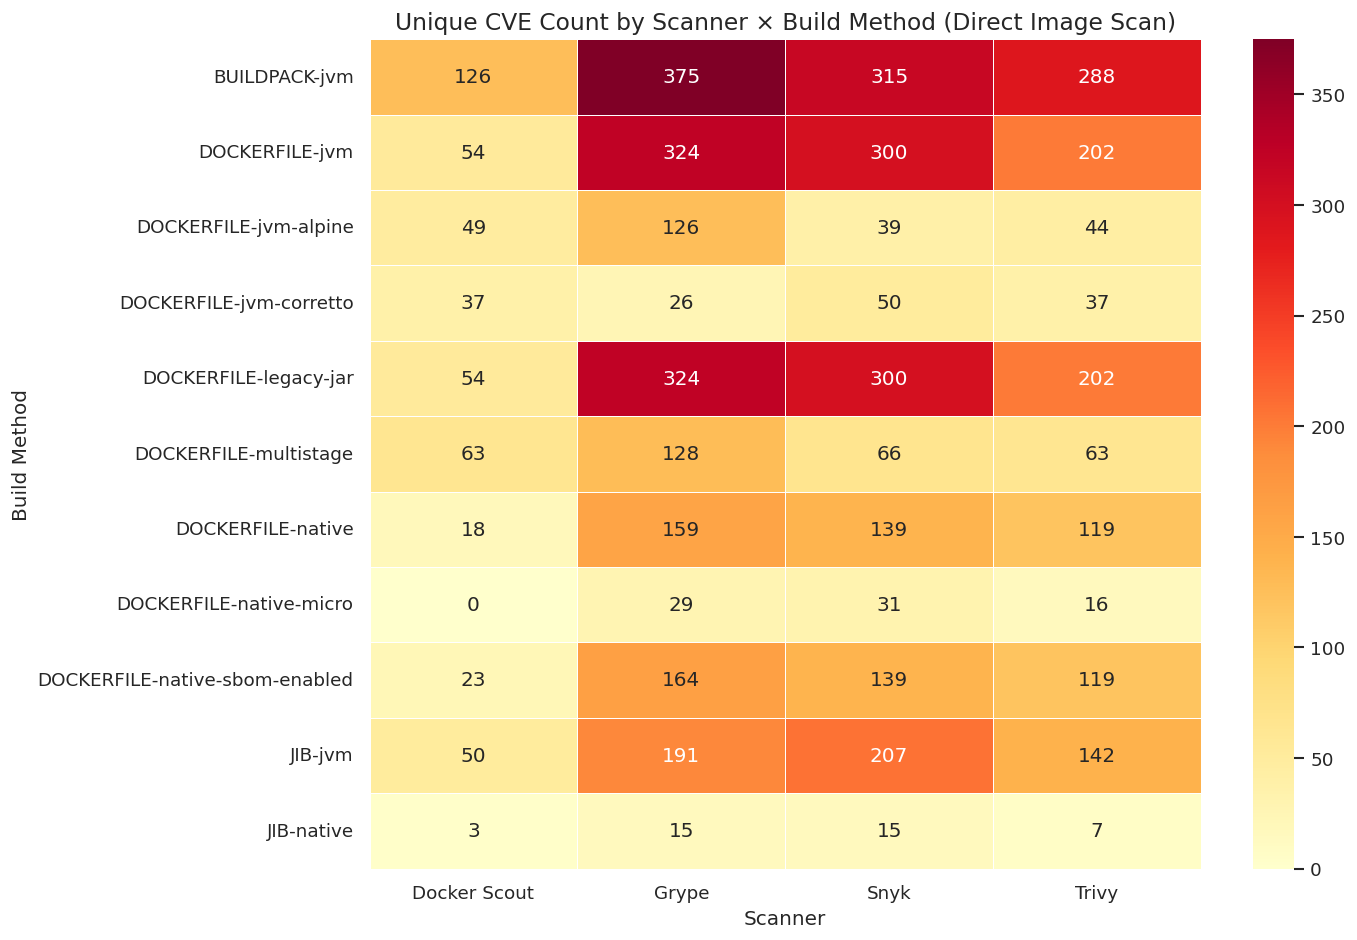

In [16]:
df_direct = df[df['scan_type'] == 'direct'].copy()

# Unique CVEs per scanner per build method
vuln_counts = df_direct.groupby(['build_method', 'scanner'])['cve_id'].nunique().reset_index()
vuln_counts.columns = ['build_method', 'scanner', 'unique_cves']

# Pivot for heatmap
pivot = vuln_counts.pivot(index='build_method', columns='scanner', values='unique_cves').fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Unique CVE Count by Scanner \u00d7 Build Method (Direct Image Scan)')
ax.set_xlabel('Scanner')
ax.set_ylabel('Build Method')
plt.tight_layout()
plt.show()

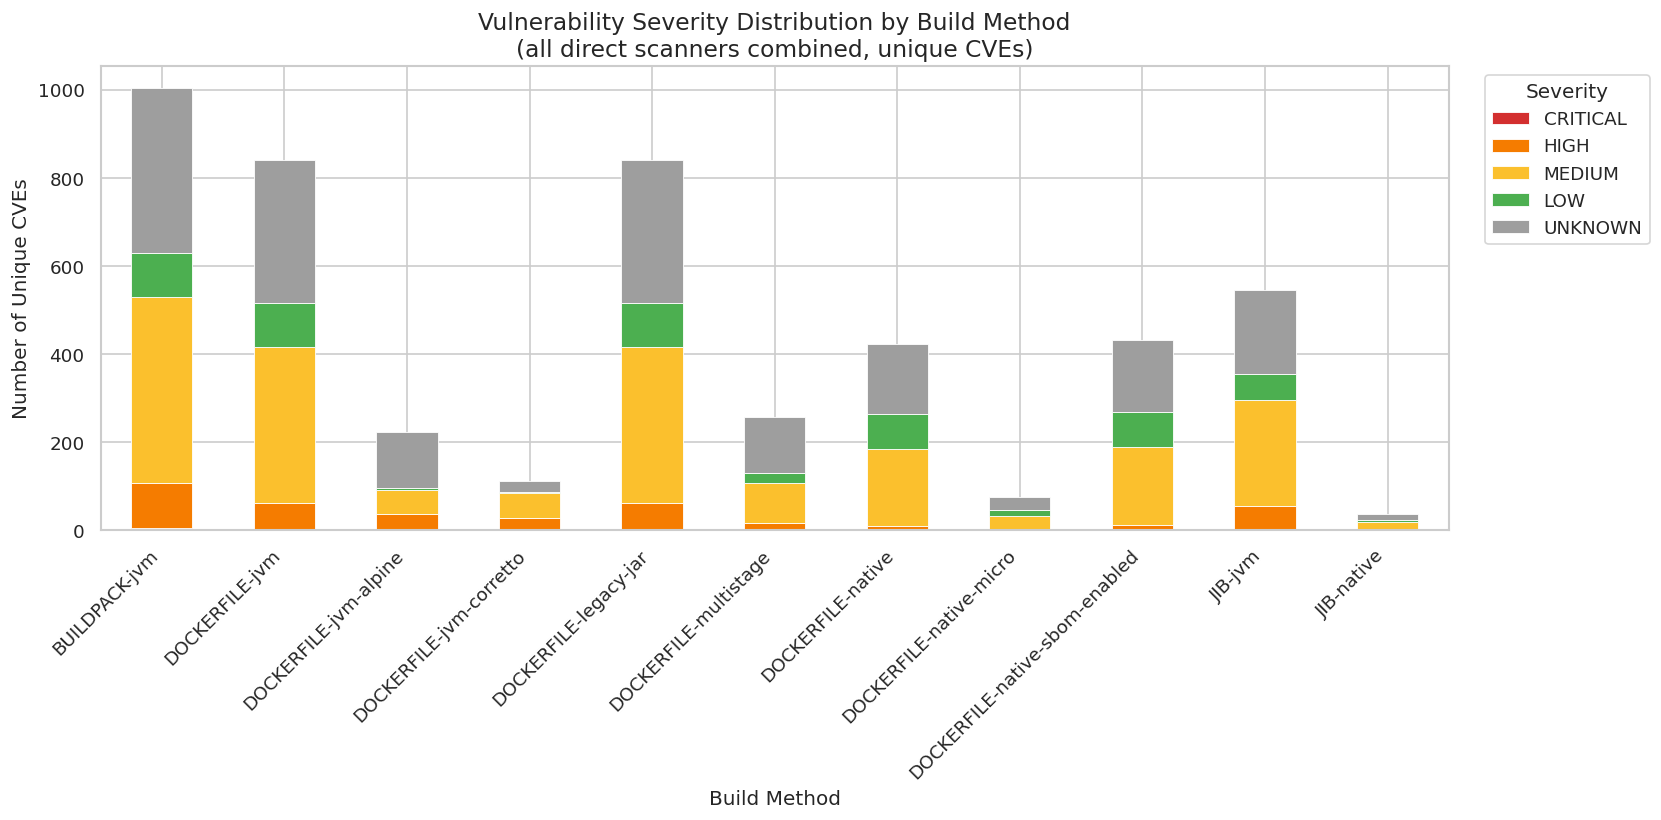

In [17]:
# Severity distribution per build method (direct scans, all scanners combined)
sev_counts = df_direct.groupby(['build_method', 'severity'])['cve_id'].nunique().reset_index()
sev_counts.columns = ['build_method', 'severity', 'count']

sev_counts['severity'] = pd.Categorical(sev_counts['severity'], categories=SEVERITY_ORDER, ordered=True)

pivot_sev = sev_counts.pivot(index='build_method', columns='severity', values='count').fillna(0).astype(int)

colors = {'CRITICAL': '#d32f2f', 'HIGH': '#f57c00', 'MEDIUM': '#fbc02d', 'LOW': '#4caf50', 'UNKNOWN': '#9e9e9e'}
color_list = [colors.get(s, '#9e9e9e') for s in pivot_sev.columns]

ax = pivot_sev.plot(kind='bar', stacked=True, figsize=(14, 7), color=color_list, edgecolor='white', linewidth=0.5)
ax.set_title('Vulnerability Severity Distribution by Build Method\n(all direct scanners combined, unique CVEs)')
ax.set_xlabel('Build Method')
ax.set_ylabel('Number of Unique CVEs')
ax.legend(title='Severity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

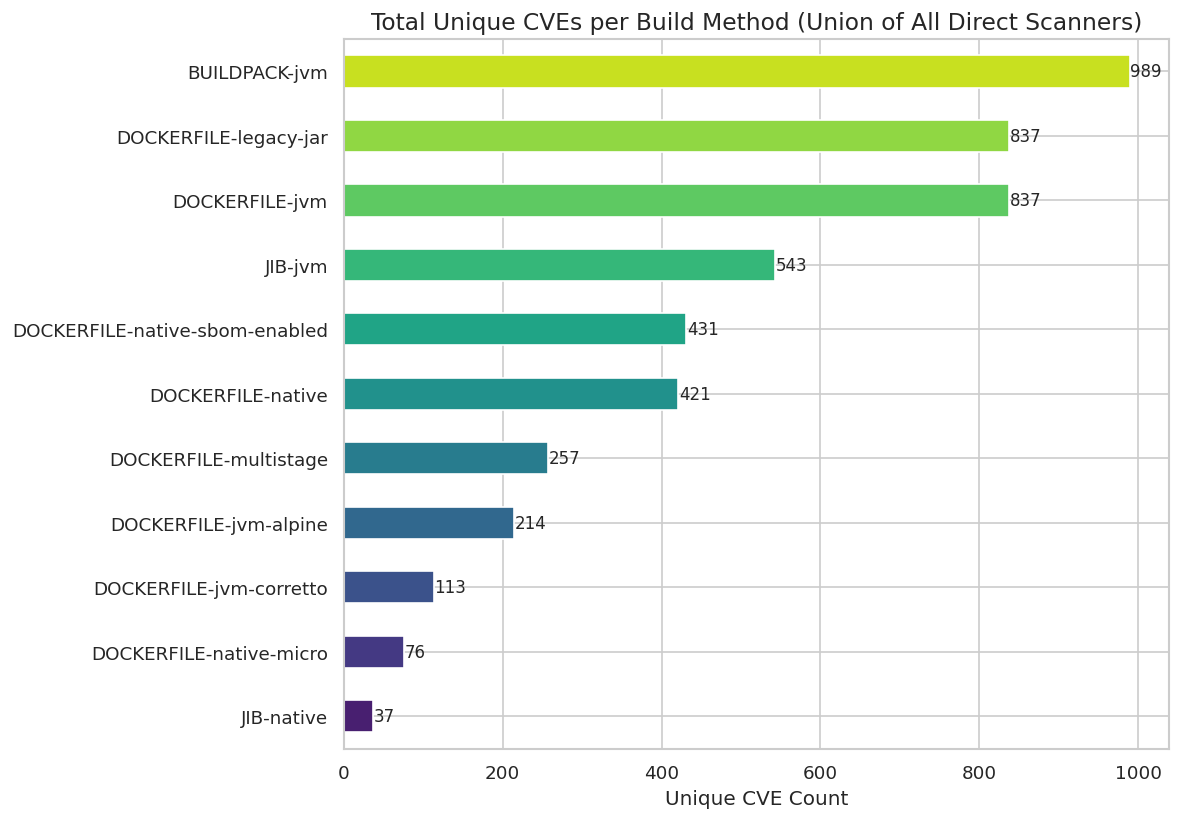

In [18]:
# Total unique CVEs per build method (union of all direct scanners)
total_unique = df_direct.groupby('build_method')['cve_id'].nunique().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = total_unique.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(total_unique)))
ax.set_title('Total Unique CVEs per Build Method (Union of All Direct Scanners)')
ax.set_xlabel('Unique CVE Count')
ax.set_ylabel('')

for i, (val, name) in enumerate(zip(total_unique.values, total_unique.index)):
    ax.text(val + 1, i, str(val), va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 4. JVM vs Native Comparison

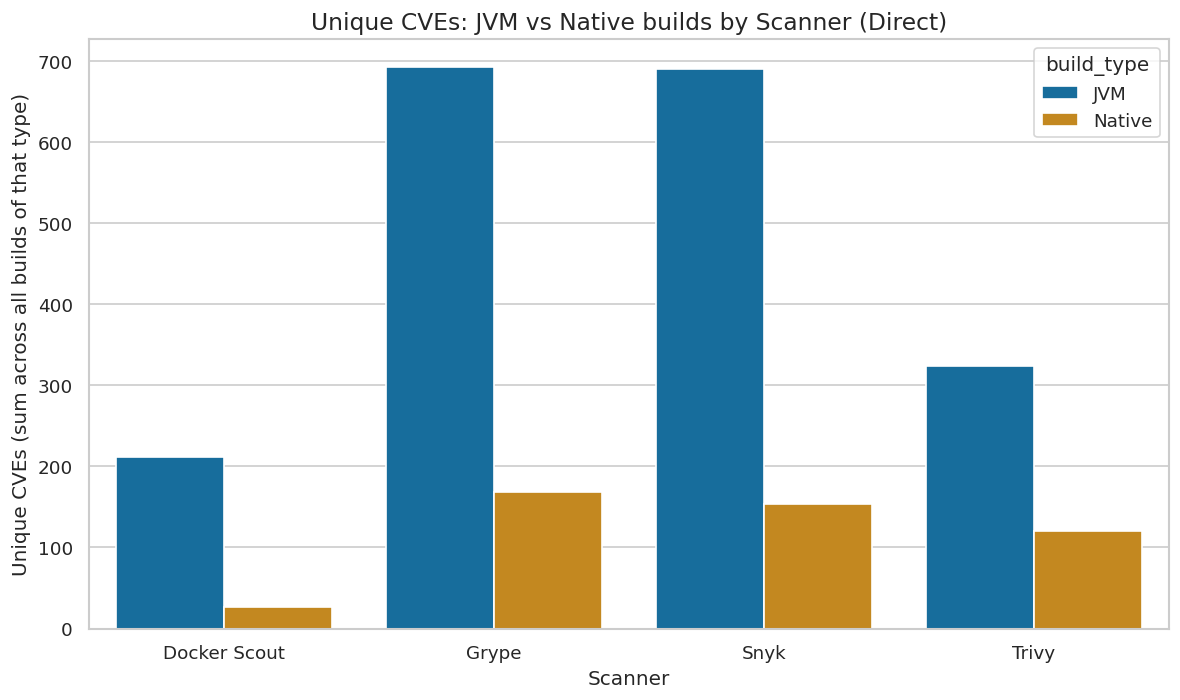

In [19]:
def classify_build(build: str) -> str:
    if 'native' in build.lower():
        return 'Native'
    return 'JVM'

df_direct['build_type'] = df_direct['build_method'].apply(classify_build)

type_comparison = df_direct.groupby(['build_type', 'scanner'])['cve_id'].nunique().reset_index()
type_comparison.columns = ['build_type', 'scanner', 'unique_cves']

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=type_comparison, x='scanner', y='unique_cves', hue='build_type', ax=ax)
ax.set_title('Unique CVEs: JVM vs Native builds by Scanner (Direct)')
ax.set_xlabel('Scanner')
ax.set_ylabel('Unique CVEs (sum across all builds of that type)')
plt.tight_layout()
plt.show()

In [20]:
# Average per build type
avg_per_type = df_direct.groupby(['build_method', 'build_type'])['cve_id'].nunique().reset_index()
avg_per_type.columns = ['build_method', 'build_type', 'unique_cves']
avg_summary = avg_per_type.groupby('build_type')['unique_cves'].agg(['mean', 'median', 'min', 'max'])
avg_summary.columns = ['Mean CVEs', 'Median CVEs', 'Min CVEs', 'Max CVEs']
avg_summary = avg_summary.round(1)
print('=== JVM vs Native: Unique CVE statistics (per build method, all direct scanners) ===')
display(avg_summary)

=== JVM vs Native: Unique CVE statistics (per build method, all direct scanners) ===


,Mean CVEs,Median CVEs,Min CVEs,Max CVEs
build_type,,,,
JVM,541.4,543.0,113,989
Native,241.2,248.5,37,431


## 5. Scanner Agreement Analysis

How much do scanners agree on the same CVEs for each build method?

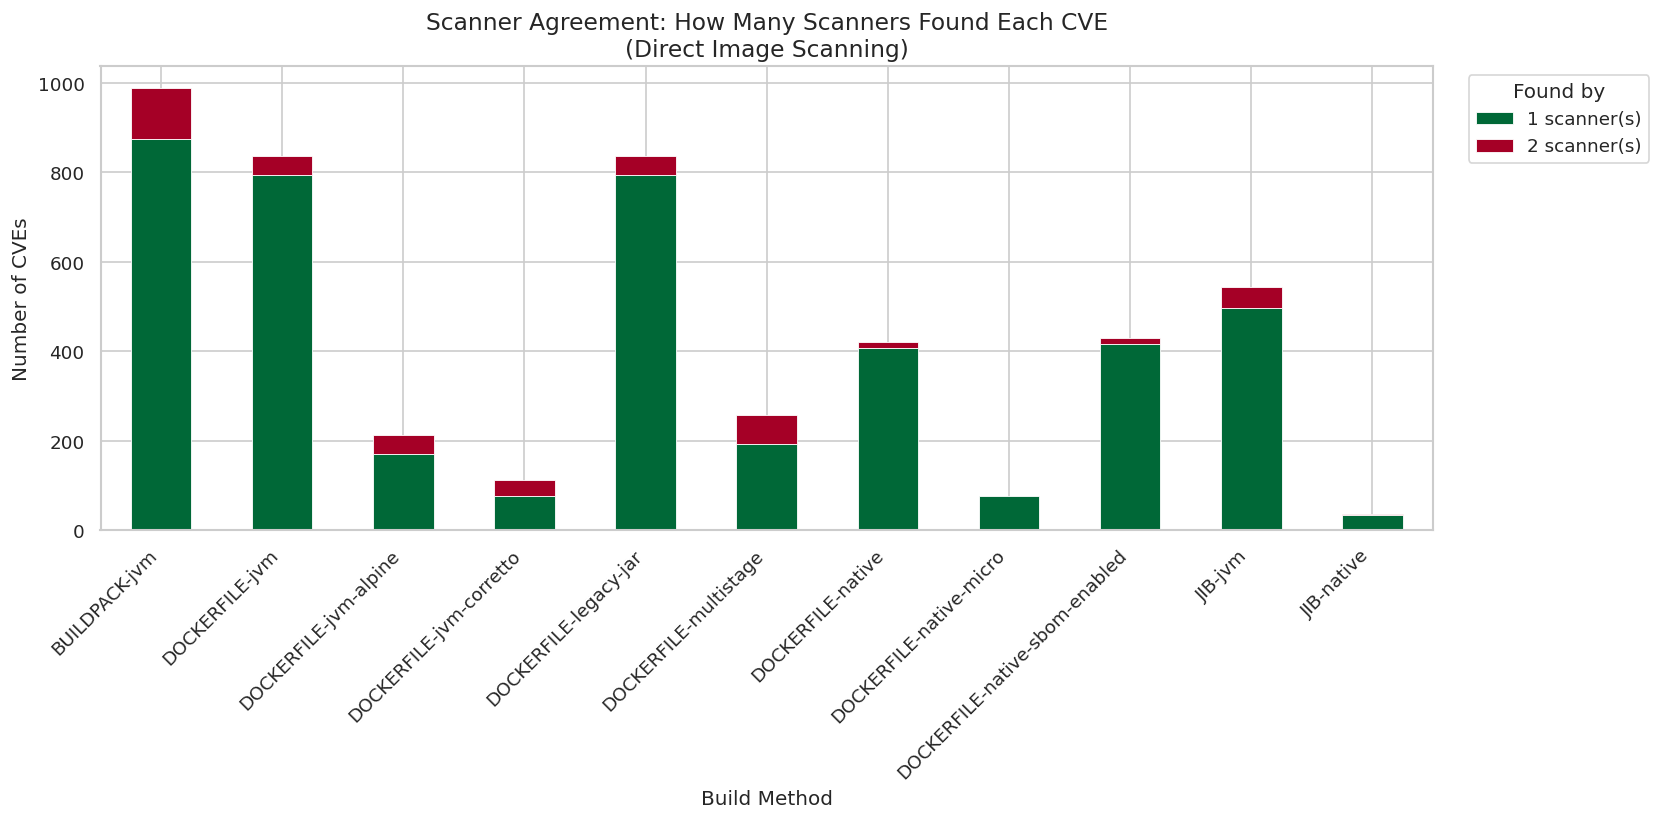

In [21]:
agreement_records = []

for build in build_methods:
    bm_df = df_direct[df_direct['build_method'] == build]
    cve_scanners = bm_df.groupby('cve_id')['scanner'].apply(set).reset_index()
    for _, row in cve_scanners.iterrows():
        agreement_records.append({
            'build_method': build,
            'cve_id': row['cve_id'],
            'num_scanners': len(row['scanner']),
            'scanners': ', '.join(sorted(row['scanner'])),
        })

df_agreement = pd.DataFrame(agreement_records)

agreement_dist = df_agreement.groupby(['build_method', 'num_scanners'])['cve_id'].count().reset_index()
agreement_dist.columns = ['build_method', 'num_scanners', 'cve_count']

pivot_agree = agreement_dist.pivot(index='build_method', columns='num_scanners', values='cve_count').fillna(0).astype(int)
pivot_agree.columns = [f'{c} scanner(s)' for c in pivot_agree.columns]

ax = pivot_agree.plot(kind='bar', stacked=True, figsize=(14, 7),
                      colormap='RdYlGn_r', edgecolor='white', linewidth=0.5)
ax.set_title('Scanner Agreement: How Many Scanners Found Each CVE\n(Direct Image Scanning)')
ax.set_xlabel('Build Method')
ax.set_ylabel('Number of CVEs')
ax.legend(title='Found by', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# CVEs found by ALL 4 scanners for a given build method
all_four = df_agreement[df_agreement['num_scanners'] == 4]
consensus_counts = all_four.groupby('build_method')['cve_id'].count()

print('=== CVEs found by ALL 4 scanners (per build method) ===')
for bm in build_methods:
    cnt = consensus_counts.get(bm, 0)
    total = df_agreement[df_agreement['build_method'] == bm]['cve_id'].nunique()
    pct = (cnt / total * 100) if total > 0 else 0
    print(f'  {bm}: {cnt} / {total} ({pct:.1f}%)')

=== CVEs found by ALL 4 scanners (per build method) ===
  BUILDPACK-jvm: 0 / 989 (0.0%)
  DOCKERFILE-jvm: 0 / 837 (0.0%)
  DOCKERFILE-jvm-alpine: 0 / 214 (0.0%)
  DOCKERFILE-jvm-corretto: 0 / 113 (0.0%)
  DOCKERFILE-legacy-jar: 0 / 837 (0.0%)
  DOCKERFILE-multistage: 0 / 257 (0.0%)
  DOCKERFILE-native: 0 / 421 (0.0%)
  DOCKERFILE-native-micro: 0 / 76 (0.0%)
  DOCKERFILE-native-sbom-enabled: 0 / 431 (0.0%)
  JIB-jvm: 0 / 543 (0.0%)
  JIB-native: 0 / 37 (0.0%)


## 6. Per-Scanner Detailed Comparison

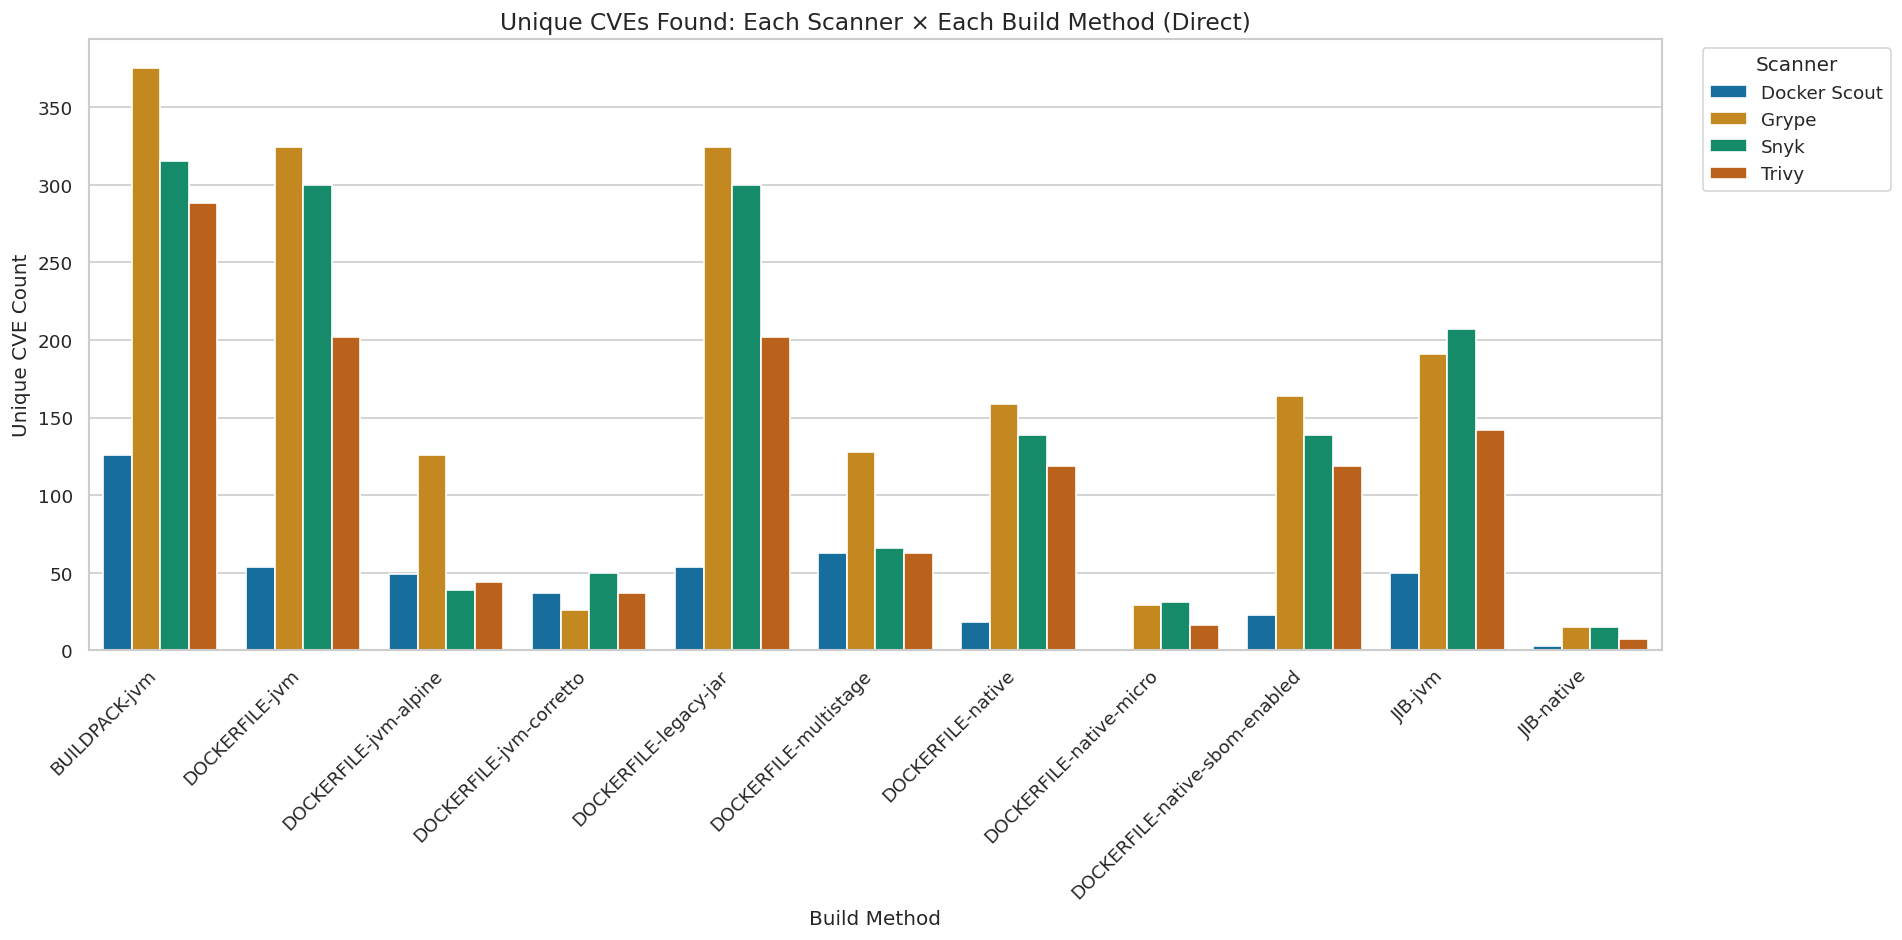

In [23]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(data=vuln_counts, x='build_method', y='unique_cves', hue='scanner', ax=ax)
ax.set_title('Unique CVEs Found: Each Scanner \u00d7 Each Build Method (Direct)')
ax.set_xlabel('Build Method')
ax.set_ylabel('Unique CVE Count')
plt.xticks(rotation=45, ha='right')
ax.legend(title='Scanner', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

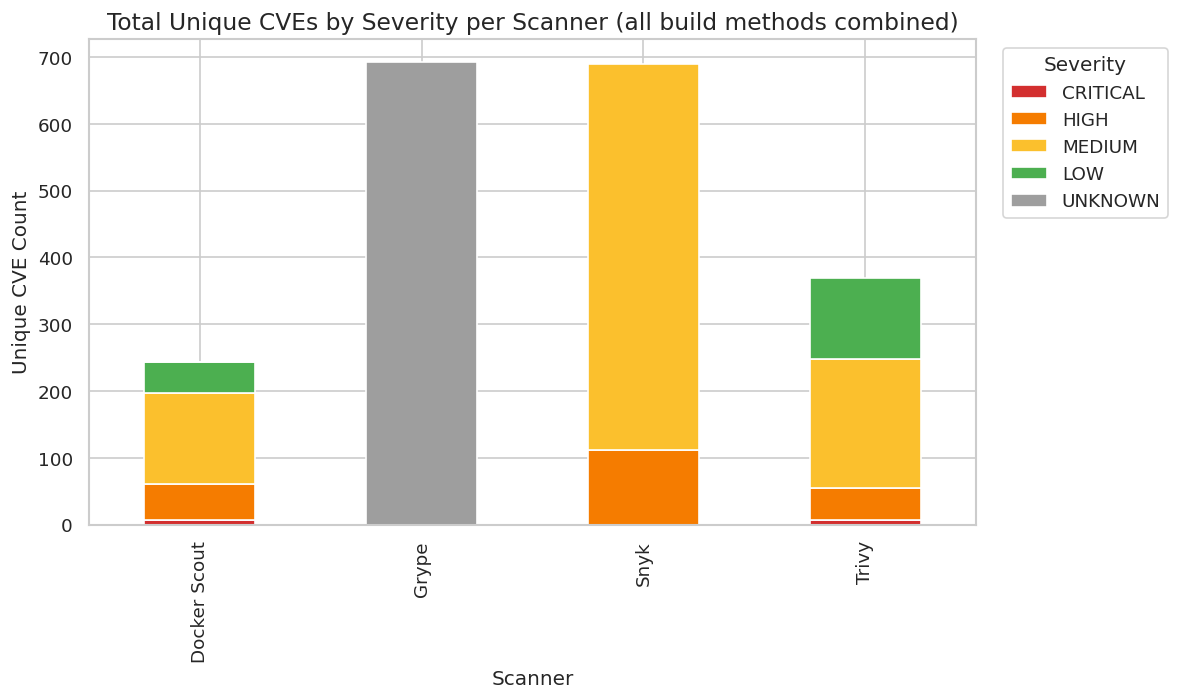

In [24]:
# Severity breakdown per scanner (aggregated across all build methods)
sev_scanner = df_direct.groupby(['scanner', 'severity'])['cve_id'].nunique().reset_index()
sev_scanner.columns = ['scanner', 'severity', 'count']
sev_scanner['severity'] = pd.Categorical(sev_scanner['severity'], categories=SEVERITY_ORDER, ordered=True)

pivot_ss = sev_scanner.pivot(index='scanner', columns='severity', values='count').fillna(0).astype(int)

color_list_ss = [colors.get(s, '#9e9e9e') for s in pivot_ss.columns]
ax = pivot_ss.plot(kind='bar', stacked=True, figsize=(10, 6), color=color_list_ss, edgecolor='white')
ax.set_title('Total Unique CVEs by Severity per Scanner (all build methods combined)')
ax.set_xlabel('Scanner')
ax.set_ylabel('Unique CVE Count')
ax.legend(title='Severity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. SBOM-Based Scan Analysis

Compare how different SBOM generators + scanner combinations affect the number of detected vulnerabilities.

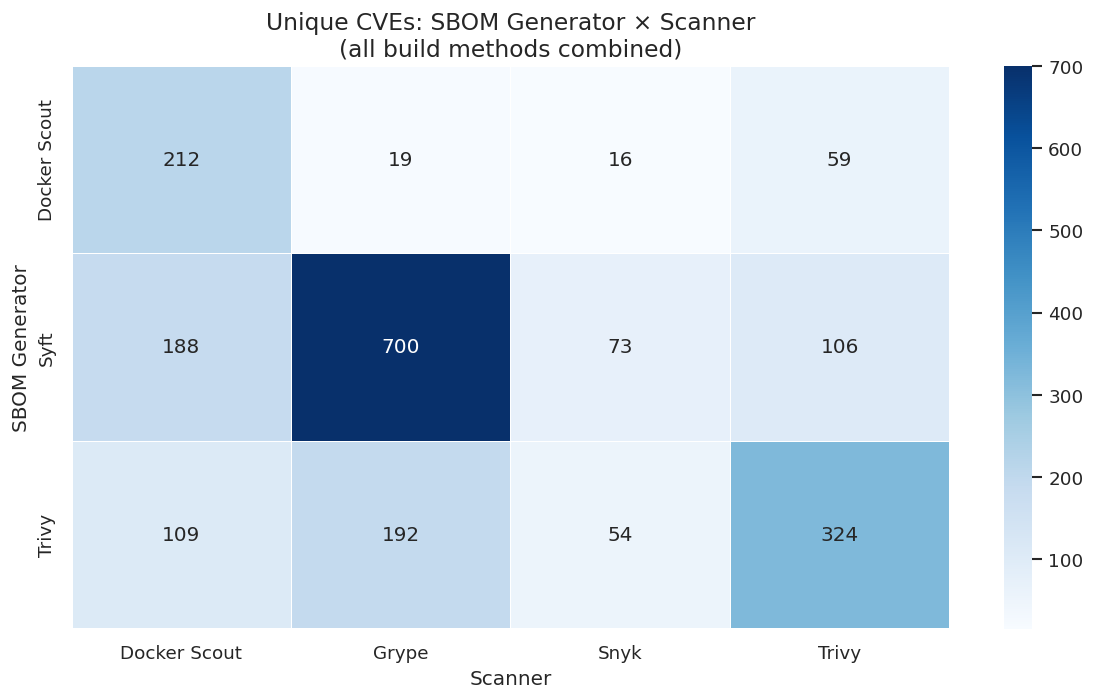

In [25]:
df_sbom = df[df['scan_type'] == 'sbom'].copy()

if len(df_sbom) > 0:
    sbom_counts = df_sbom.groupby(['sbom_generator', 'scanner'])['cve_id'].nunique().reset_index()
    sbom_counts.columns = ['sbom_generator', 'scanner', 'unique_cves']

    pivot_sbom = sbom_counts.pivot(index='sbom_generator', columns='scanner', values='unique_cves').fillna(0).astype(int)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot_sbom, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title('Unique CVEs: SBOM Generator \u00d7 Scanner\n(all build methods combined)')
    ax.set_xlabel('Scanner')
    ax.set_ylabel('SBOM Generator')
    plt.tight_layout()
    plt.show()
else:
    print('No SBOM-based scan results found.')

In [26]:
if len(df_sbom) > 0:
    compare_records = []
    for build in build_methods:
        for scanner in ['Trivy', 'Grype', 'Docker Scout']:
            direct_cves = set(df_direct[(df_direct['build_method'] == build) &
                                        (df_direct['scanner'] == scanner)]['cve_id'])
            for gen in SBOM_GENERATORS.values():
                sbom_cves = set(df_sbom[(df_sbom['build_method'] == build) &
                                        (df_sbom['scanner'] == scanner) &
                                        (df_sbom['sbom_generator'] == gen)]['cve_id'])
                if len(direct_cves) > 0 or len(sbom_cves) > 0:
                    compare_records.append({
                        'build_method': build,
                        'scanner': scanner,
                        'sbom_generator': gen,
                        'direct_only': len(direct_cves - sbom_cves),
                        'sbom_only': len(sbom_cves - direct_cves),
                        'overlap': len(direct_cves & sbom_cves),
                        'direct_total': len(direct_cves),
                        'sbom_total': len(sbom_cves),
                    })

    df_compare = pd.DataFrame(compare_records)
    agg_compare = df_compare.groupby(['scanner', 'sbom_generator'])[['direct_only', 'sbom_only', 'overlap']].sum().reset_index()
    print('=== Direct vs SBOM Scan Comparison (totals across all build methods) ===')
    display(agg_compare)

=== Direct vs SBOM Scan Comparison (totals across all build methods) ===


,scanner,sbom_generator,direct_only,sbom_only,overlap
0,Docker Scout,Docker Scout,0,0,477
1,Docker Scout,Syft,71,0,406
2,Docker Scout,Trivy,314,0,163
3,Grype,Docker Scout,1858,85,3
4,Grype,Syft,0,27,1861
5,Grype,Trivy,1282,73,579
6,Trivy,Docker Scout,1128,17,111
7,Trivy,Syft,1072,17,167
8,Trivy,Trivy,0,0,1239


## 8. SBOM-Based Scanning Heatmap per Build Method

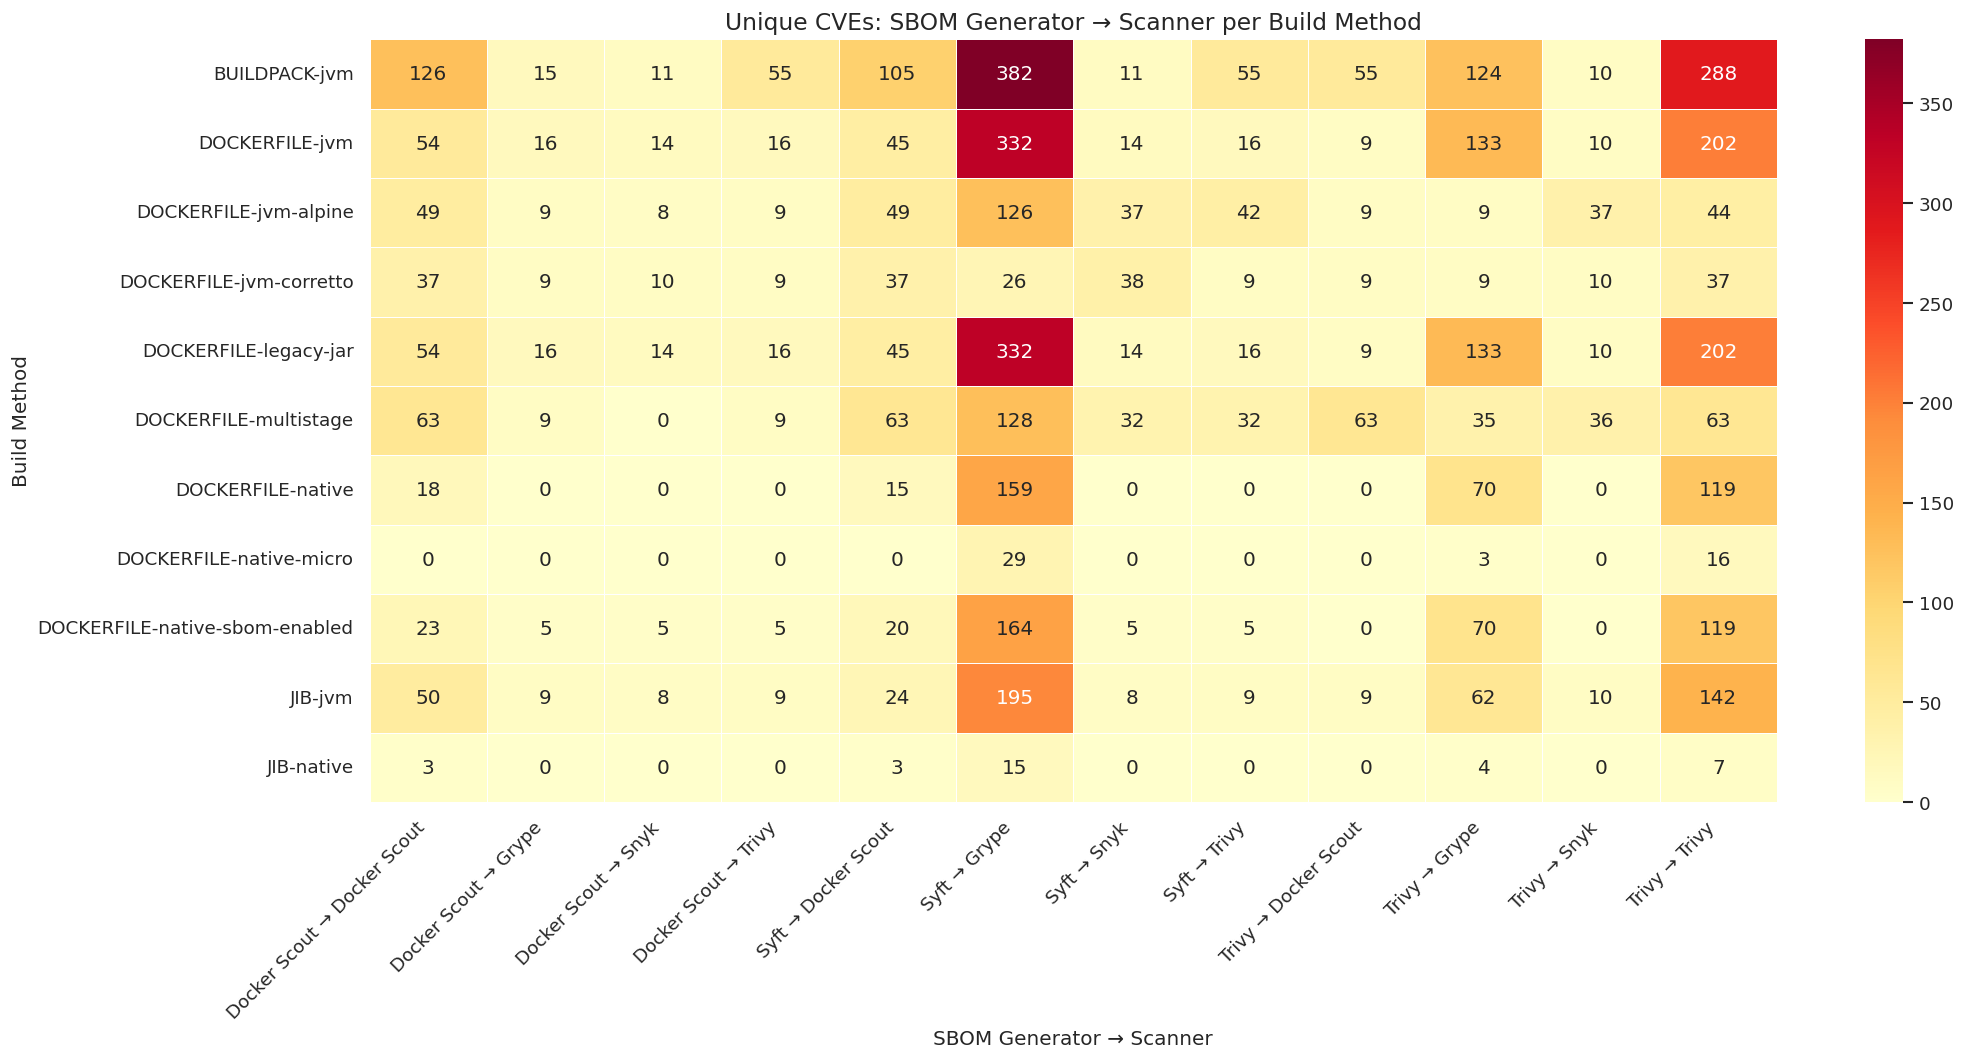

In [27]:
if len(df_sbom) > 0:
    df_sbom['sbom_scanner_combo'] = df_sbom['sbom_generator'] + ' \u2192 ' + df_sbom['scanner']

    sbom_per_build = df_sbom.groupby(['build_method', 'sbom_scanner_combo'])['cve_id'].nunique().reset_index()
    sbom_per_build.columns = ['build_method', 'sbom_scanner_combo', 'unique_cves']

    pivot_sbom_build = sbom_per_build.pivot(index='build_method', columns='sbom_scanner_combo', values='unique_cves').fillna(0).astype(int)

    fig, ax = plt.subplots(figsize=(18, 9))
    sns.heatmap(pivot_sbom_build, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
    ax.set_title('Unique CVEs: SBOM Generator \u2192 Scanner per Build Method')
    ax.set_xlabel('SBOM Generator \u2192 Scanner')
    ax.set_ylabel('Build Method')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 9. Top Critical & High CVEs Across Builds

In [28]:
df_critical_high = df_direct[df_direct['severity'].isin(['CRITICAL', 'HIGH'])].copy()

cve_spread = df_critical_high.groupby('cve_id').agg(
    num_builds=('build_method', 'nunique'),
    severity=('severity', 'first'),
    package=('package', 'first'),
    scanners=('scanner', lambda x: ', '.join(sorted(set(x)))),
    max_cvss=('cvss', 'max'),
).reset_index().sort_values(['num_builds', 'max_cvss'], ascending=[False, False])

print(f'Total CRITICAL/HIGH unique CVEs across all builds: {len(cve_spread)}')
print(f'\nTop 20 most widespread CRITICAL/HIGH CVEs:')
display(cve_spread.head(20))

Total CRITICAL/HIGH unique CVEs across all builds: 184

Top 20 most widespread CRITICAL/HIGH CVEs:


,cve_id,num_builds,severity,package,scanners,max_cvss
51,CVE-2025-68973,9,HIGH,gnupg2,"Docker Scout, Trivy",8.0
6,CVE-2022-42889,8,CRITICAL,org.apache.commons:commons-text,"Docker Scout, Trivy",9.8
72,GHSA-72hv-8253-57qq,8,HIGH,com.fasterxml.jackson.core:jackson-core,"Docker Scout, Trivy",8.7
1,CVE-2015-7501,7,CRITICAL,commons-collections:commons-collections,"Docker Scout, Trivy",9.8
3,CVE-2020-10683,7,CRITICAL,org.dom4j:dom4j,"Docker Scout, Trivy",9.8
88,SNYK-JAVA-COMMONSCOLLECTIONS-30078,7,HIGH,,Snyk,9.8
89,SNYK-JAVA-COMMONSCOLLECTIONS-472711,7,HIGH,,Snyk,9.8
90,SNYK-JAVA-COMMONSCOLLECTIONS-6056408,7,HIGH,,Snyk,9.8
87,SNYK-JAVA-COMFASTERXMLJACKSONCORE-15365924,7,HIGH,,Snyk,8.7
93,SNYK-JAVA-IOQUARKUSVERTXUTILS-14897052,7,HIGH,,Snyk,8.2


CVEs unique to JVM builds: 1268
CVEs unique to Native builds: 0
CVEs shared between JVM and Native: 451


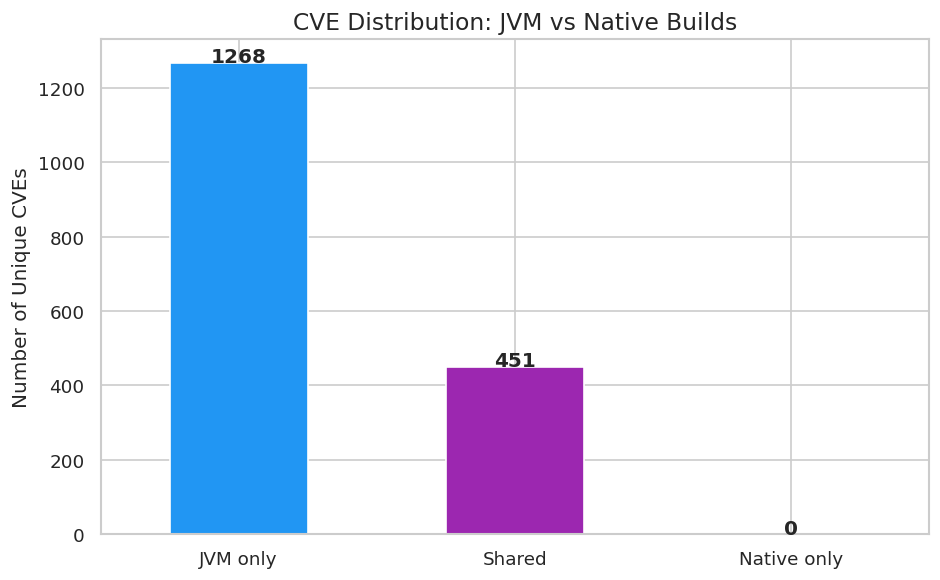

In [29]:
# CVEs unique to native builds vs JVM builds
df_direct_typed = df_direct.copy()
df_direct_typed['build_type'] = df_direct_typed['build_method'].apply(classify_build)

jvm_cves = set(df_direct_typed[df_direct_typed['build_type'] == 'JVM']['cve_id'])
native_cves = set(df_direct_typed[df_direct_typed['build_type'] == 'Native']['cve_id'])

only_jvm = jvm_cves - native_cves
only_native = native_cves - jvm_cves
shared = jvm_cves & native_cves

print(f'CVEs unique to JVM builds: {len(only_jvm)}')
print(f'CVEs unique to Native builds: {len(only_native)}')
print(f'CVEs shared between JVM and Native: {len(shared)}')

venn_data = pd.Series({'JVM only': len(only_jvm), 'Shared': len(shared), 'Native only': len(only_native)})
fig, ax = plt.subplots(figsize=(8, 5))
venn_data.plot(kind='bar', color=['#2196f3', '#9c27b0', '#4caf50'], ax=ax, edgecolor='white')
ax.set_title('CVE Distribution: JVM vs Native Builds')
ax.set_ylabel('Number of Unique CVEs')
for i, v in enumerate(venn_data.values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Summary Statistics Table

In [30]:
summary_records = []
for build in build_methods:
    bm_df = df_direct[df_direct['build_method'] == build]
    all_cves = bm_df['cve_id'].nunique()
    crit = bm_df[bm_df['severity'] == 'CRITICAL']['cve_id'].nunique()
    high = bm_df[bm_df['severity'] == 'HIGH']['cve_id'].nunique()
    med = bm_df[bm_df['severity'] == 'MEDIUM']['cve_id'].nunique()
    low = bm_df[bm_df['severity'] == 'LOW']['cve_id'].nunique()
    unknown = bm_df[bm_df['severity'] == 'UNKNOWN']['cve_id'].nunique()
    build_type = classify_build(build)
    summary_records.append({
        'Build Method': build,
        'Type': build_type,
        'Total CVEs': all_cves,
        'Critical': crit,
        'High': high,
        'Medium': med,
        'Low': low,
        'Unknown': unknown,
    })

df_summary = pd.DataFrame(summary_records).sort_values('Total CVEs', ascending=False)
print('=== Summary: Unique CVEs per Build Method (Direct Scans, All Scanners Combined) ===')
display(df_summary.style.background_gradient(subset=['Total CVEs', 'Critical', 'High'], cmap='YlOrRd'))

=== Summary: Unique CVEs per Build Method (Direct Scans, All Scanners Combined) ===


,Build Method,Type,Total CVEs,Critical,High,Medium,Low,Unknown
0,BUILDPACK-jvm,JVM,989,6,101,423,99,375
1,DOCKERFILE-jvm,JVM,837,3,60,352,101,324
4,DOCKERFILE-legacy-jar,JVM,837,3,60,352,101,324
9,JIB-jvm,JVM,543,3,52,240,59,191
8,DOCKERFILE-native-sbom-enabled,Native,431,1,11,177,79,164
6,DOCKERFILE-native,Native,421,0,10,174,79,159
5,DOCKERFILE-multistage,JVM,257,3,13,91,22,128
2,DOCKERFILE-jvm-alpine,JVM,214,4,32,55,5,127
3,DOCKERFILE-jvm-corretto,JVM,113,3,25,56,3,26
7,DOCKERFILE-native-micro,Native,76,0,0,33,14,29


## 11. CVSS Score Distribution

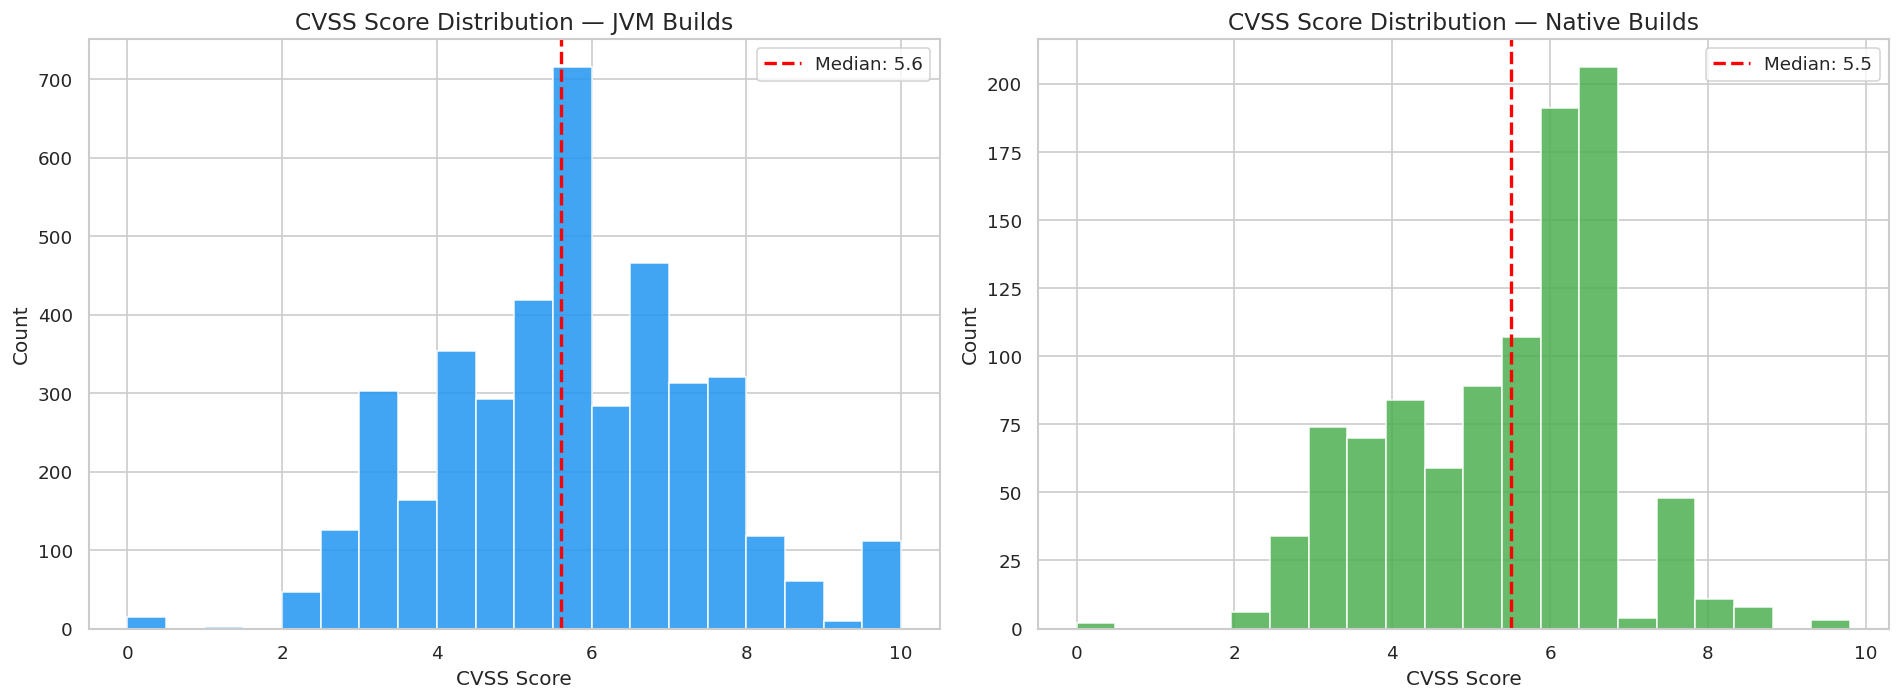

In [31]:
df_cvss = df_direct[df_direct['cvss'].notna()].copy()
df_cvss['build_type'] = df_cvss['build_method'].apply(classify_build)

if len(df_cvss) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, bt in zip(axes, ['JVM', 'Native']):
        subset = df_cvss[df_cvss['build_type'] == bt]['cvss']
        if len(subset) > 0:
            ax.hist(subset, bins=20, color='#2196f3' if bt == 'JVM' else '#4caf50',
                    edgecolor='white', alpha=0.85)
            ax.axvline(subset.median(), color='red', linestyle='--', linewidth=2,
                      label=f'Median: {subset.median():.1f}')
            ax.set_title(f'CVSS Score Distribution \u2014 {bt} Builds')
            ax.set_xlabel('CVSS Score')
            ax.set_ylabel('Count')
            ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print('No CVSS score data available.')

## 12. Key Findings Summary

In [32]:
print('=' * 70)
print('KEY FINDINGS')
print('=' * 70)

print(f'\n1. DATA SCOPE')
print(f'   - {len(build_methods)} build methods analyzed')
print(f'   - {len(df)} total vulnerability records')
print(f'   - {df["cve_id"].nunique()} unique CVE identifiers across all scans')

most_vuln = df_summary.iloc[0]
least_vuln = df_summary.iloc[-1]
print(f'\n2. BUILD METHOD COMPARISON (direct scans)')
print(f'   - Most vulnerabilities: {most_vuln["Build Method"]} ({most_vuln["Total CVEs"]} unique CVEs)')
print(f'   - Least vulnerabilities: {least_vuln["Build Method"]} ({least_vuln["Total CVEs"]} unique CVEs)')
print(f'   - Reduction factor: {most_vuln["Total CVEs"] / max(least_vuln["Total CVEs"], 1):.1f}x')

print(f'\n3. JVM vs NATIVE')
print(f'   - JVM-only CVEs: {len(only_jvm)}')
print(f'   - Native-only CVEs: {len(only_native)}')
print(f'   - Shared CVEs: {len(shared)}')

total_agreement_4 = len(df_agreement[df_agreement['num_scanners'] == 4])
total_cves_all = len(df_agreement)
print(f'\n4. SCANNER AGREEMENT')
print(f'   - CVEs found by all 4 scanners: {total_agreement_4} / {total_cves_all} ({total_agreement_4/max(total_cves_all,1)*100:.1f}%)')
single_scanner = len(df_agreement[df_agreement['num_scanners'] == 1])
print(f'   - CVEs found by only 1 scanner: {single_scanner} / {total_cves_all} ({single_scanner/max(total_cves_all,1)*100:.1f}%)')

print(f'\n{"=" * 70}')

KEY FINDINGS

1. DATA SCOPE
   - 11 build methods analyzed
   - 10767 total vulnerability records
   - 1760 unique CVE identifiers across all scans

2. BUILD METHOD COMPARISON (direct scans)
   - Most vulnerabilities: BUILDPACK-jvm (989 unique CVEs)
   - Least vulnerabilities: JIB-native (37 unique CVEs)
   - Reduction factor: 26.7x

3. JVM vs NATIVE
   - JVM-only CVEs: 1268
   - Native-only CVEs: 0
   - Shared CVEs: 451

4. SCANNER AGREEMENT
   - CVEs found by all 4 scanners: 0 / 4755 (0.0%)
   - CVEs found by only 1 scanner: 4332 / 4755 (91.1%)

